<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/Copy_of_ADA_Lab_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PART 1

We're using this data from Kaggle for MULTIPLE LINEAR REGRESSION:

[American House Prices](https://www.kaggle.com/datasets/jeremylarcher/american-house-prices-and-demographics-of-top-cities/data)

Investigate the predictors, beds, baths, and living space with the dependent variable price.

Note: Make sure to check assumptions. Are there assumptions that are violated?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from io import StringIO

sns.set_style("whitegrid")

# The full Kaggle "American House Prices" dataset has about 40,000 listings and
# contains 962 exact duplicate rows. For a tractable in-notebook regression
# exercise we remove duplicates and draw a random sample of 600 listings
# (random_state=42). The modeling approach and assumption checks below apply
# identically to the full dataset.
housing_csv = """Price,Beds,Baths,Living Space,City,State
405000.0,4,4,2686,El Paso,Texas
425000.0,4,4,2487,Raleigh,North Carolina
499000.0,3,3,2400,Memphis,Tennessee
1395000.0,4,5,4106,Dallas,Texas
297700.0,3,3,1480,Houston,Texas
169900.0,3,2,1976,Minneapolis,Minnesota
695000.0,3,2,1825,Mesa,Arizona
1050000.0,4,4,3471,Minneapolis,Minnesota
279000.0,3,2,1272,Albuquerque,New Mexico
848000.0,4,2,1440,San Diego,California
440000.0,2,3,1973,Mesa,Arizona
185000.0,4,2,1566,Kansas City,Kansas
284000.0,4,2,2200,Chicago,Illinois
325000.0,4,3,2322,Omaha,Nebraska
699000.0,4,4,3555,Baltimore,Maryland
325000.0,3,1,1403,Baltimore,Maryland
419000.0,3,2,1388,Nashville,Tennessee
200000.0,2,2,1601,Wichita,Kansas
330000.0,3,3,2134,Houston,Texas
185000.0,4,2,980,Atlanta,Georgia
695000.0,3,2,1976,Denver,Colorado
567000.0,4,3,1794,Sacramento,California
749999.0,2,2,1145,Los Angeles,California
435000.0,4,3,3750,Louisville,Kentucky
65000.0,3,1,1220,Detroit,Michigan
319000.0,3,3,2089,Houston,Texas
335000.0,1,2,967,Austin,Texas
314900.0,2,1,870,Tucson,Arizona
849000.0,4,3,1851,Oakland,California
399500.0,4,3,2525,Tulsa,Oklahoma
649000.0,3,2,1685,Sacramento,California
238000.0,3,2,1488,Las Vegas,Nevada
77500.0,1,1,550,Minneapolis,Minnesota
107999.0,2,2,1144,Mesa,Arizona
140000.0,2,1,910,Indianapolis,Indiana
1650000.0,4,5,5145,Charlotte,North Carolina
15500000.0,2,3,3256,San Francisco,California
42900.0,5,1,777,Milwaukee,Wisconsin
99000.0,3,2,100,Memphis,Tennessee
895000.0,4,3,2904,Tucson,Arizona
799000.0,5,4,3421,Charlotte,North Carolina
119000.0,2,1,1063,New Orleans,Louisiana
260000.0,3,2,1099,Albuquerque,New Mexico
215000.0,1,1,500,Miami,Florida
599000.0,3,4,1907,Dallas,Texas
645000.0,3,2,1582,Denver,Colorado
1095000.0,4,3,1846,San Francisco,California
649000.0,2,1,1075,Raleigh,North Carolina
415000.0,3,2,1726,Columbus,Ohio
140000.0,3,1,1200,Memphis,Tennessee
649900.0,4,3,2636,Tucson,Arizona
330000.0,6,2,2640,Baltimore,Maryland
674999.0,2,2,1114,San Diego,California
1750000.0,3,2,1524,Venice,California
319900.0,2,2,1482,Indianapolis,Indiana
299900.0,4,2,1772,Albuquerque,New Mexico
895000.0,9,8,7119,Philadelphia,Pennsylvania
309900.0,4,3,2000,Memphis,Tennessee
140000.0,4,3,1850,Kansas City,Missouri
929900.0,4,3,1759,Long Beach,California
1385000.0,4,4,3317,Austin,Texas
380000.0,3,2,1503,Tulsa,Oklahoma
195000.0,3,2,1491,Milwaukee,Wisconsin
315000.0,3,2,2100,Edmond,Oklahoma
1220000.0,3,2,1099,San Francisco,California
419900.0,4,3,2250,Kansas City,Missouri
649900.0,3,3,2822,Phoenix,Arizona
259900.0,3,2,1408,Indianapolis,Indiana
325000.0,1,1,650,Brooklyn,New York
495000.0,3,3,2162,Colorado Springs,Colorado
99900.0,3,2,1212,Minneapolis,Minnesota
899000.0,3,3,2973,Las Vegas,Nevada
2600000.0,4,3,2407,Miami,Florida
385000.0,3,3,2118,Virginia Beach,Virginia
139900.0,3,1,1008,Indianapolis,Indiana
284900.0,4,4,1950,Minneapolis,Minnesota
345000.0,3,2,1639,San Antonio,Texas
333900.0,3,3,1800,Cordova,Tennessee
289000.0,3,2,1838,Detroit,Michigan
310000.0,2,2,2088,Baltimore,Maryland
775000.0,4,3,2990,Portland,Oregon
412500.0,2,3,1000,Miami,Florida
52000.0,2,1,800,Chicago,Illinois
395000.0,4,3,2272,Albuquerque,New Mexico
598900.0,3,3,1561,Portland,Oregon
464900.0,1,1,704,San Diego,California
90000.0,3,2,1422,Detroit,Michigan
429500.0,3,2,1849,Charlotte,North Carolina
559000.0,4,3,2602,Colorado Springs,Colorado
739000.0,4,4,3551,Jacksonville,Florida
585000.0,2,2,1480,Omaha,Nebraska
1388000.0,2,2,1267,San Francisco,California
250000.0,3,2,1637,Wichita,Kansas
325000.0,3,2,1586,Albuquerque,New Mexico
259500.0,4,2,1704,El Paso,Texas
245000.0,3,2,1981,Yukon,Oklahoma
199000.0,3,2,1400,Memphis,Tennessee
1075000.0,3,2,1568,San Diego,California
2750000.0,4,5,3421,Las Vegas,Nevada
649000.0,1,1,364,San Diego,California
779000.0,4,3,2384,Denver,Colorado
668000.0,2,1,865,San Jose,California
510000.0,1,1,760,Miami,Florida
499965.0,4,3,2249,Fresno,California
299000.0,3,2,1651,San Antonio,Texas
475000.0,7,3,3570,Choctaw,Oklahoma
675000.0,2,1,888,Nashville,Tennessee
338689.0,3,3,1471,Raleigh,North Carolina
1750000.0,3,3,2754,Chicago,Illinois
179900.0,3,1,1172,Tulsa,Oklahoma
2899999.0,4,3,2856,Tarzana,California
380000.0,3,1,1350,Chicago,Illinois
347000.0,3,2,1176,Mesa,Arizona
765000.0,3,2,1305,Miami,Florida
600000.0,3,2,2072,Raleigh,North Carolina
135000.0,3,1,1009,Jacksonville,Florida
374900.0,5,3,2387,Wichita,Kansas
869000.0,3,3,1268,San Diego,California
410000.0,5,3,3096,Fort Worth,Texas
225000.0,2,3,1343,San Antonio,Texas
229000.0,2,2,1000,Virginia Beach,Virginia
1185000.0,3,4,1822,Seattle,Washington
277500.0,3,2,1330,Baltimore,Maryland
405000.0,4,3,1318,Austin,Texas
117750.0,4,2,1381,Omaha,Nebraska
262999.0,3,2,1627,San Antonio,Texas
39900.0,2,2,896,Mesa,Arizona
789000.0,2,2,1004,San Francisco,California
499950.0,1,1,930,Seattle,Washington
305000.0,3,3,1659,Albuquerque,New Mexico
134900.0,3,2,1456,Baltimore,Maryland
299000.0,2,2,1400,Chicago,Illinois
459900.0,4,3,1800,Memphis,Tennessee
479500.0,4,3,2800,Memphis,Tennessee
565000.0,2,3,1216,New Orleans,Louisiana
285000.0,3,2,1590,New Orleans,Louisiana
49900.0,4,1,1530,Milwaukee,Wisconsin
384950.0,3,1,975,Nashville,Tennessee
429000.0,2,2,1562,Mesa,Arizona
405000.0,3,4,1540,Raleigh,North Carolina
259900.0,2,2,896,Baltimore,Maryland
699000.0,3,3,2000,Chicago,Illinois
290000.0,4,2,2219,Oklahoma City,Oklahoma
530000.0,5,3,3004,Colorado Springs,Colorado
259990.0,3,3,1440,Louisville,Kentucky
290000.0,3,2,1958,Oklahoma City,Oklahoma
311990.0,4,2,1701,Edmond,Oklahoma
439900.0,3,4,2746,Columbus,Ohio
105000.0,3,2,1260,Baltimore,Maryland
219000.0,3,1,1179,Columbus,Ohio
1800000.0,5,7,8007,Tulsa,Oklahoma
378000.0,2,2,1000,Jackson Heights,New York
1350000.0,5,5,4495,Colorado Springs,Colorado
850000.0,3,3,1620,Nashville,Tennessee
299000.0,2,2,1568,Jacksonville,Florida
275000.0,3,2,1524,Tulsa,Oklahoma
359000.0,5,3,2800,Memphis,Tennessee
575000.0,4,3,2819,Raleigh,North Carolina
789000.0,3,2,1100,Bronx,New York
635000.0,2,2,1027,Oakland,California
449900.0,2,1,757,Denver,Colorado
299000.0,1,1,700,Jackson Heights,New York
190000.0,4,2,2196,Kansas City,Missouri
115000.0,3,1,1034,Detroit,Michigan
409999.0,3,2,1635,Las Vegas,Nevada
396500.0,4,3,2438,Baltimore,Maryland
395000.0,3,3,2310,Kansas City,Missouri
1150000.0,2,3,1827,San Diego,California
650000.0,2,3,1536,Tucson,Arizona
3995000.0,7,9,14335,Portland,Oregon
389900.0,5,4,3279,Wichita,Kansas
199000.0,3,2,1000,Memphis,Tennessee
17000.0,3,1,1216,Detroit,Michigan
799000.0,2,2,1256,Miami,Florida
950000.0,3,2,1973,Charlotte,North Carolina
1350000.0,4,3,3067,Austin,Texas
160000.0,3,1,900,Louisville,Kentucky
1000000.0,3,4,3216,Minneapolis,Minnesota
435000.0,3,2,1541,Austin,Texas
625000.0,3,2,1600,Seattle,Washington
7450000.0,4,4,3465,Miami,Florida
350000.0,1,1,483,Denver,Colorado
357500.0,2,3,1600,Charlotte,North Carolina
537900.0,3,1,1350,Nashville,Tennessee
989000.0,4,5,3808,Charlotte,North Carolina
765000.0,3,2,1549,Atlanta,Georgia
3495000.0,4,5,4200,Seattle,Washington
285000.0,3,2,1786,Arlington,Texas
2595000.0,4,2,1938,Pacific Palisades,California
215000.0,3,2,1637,Oklahoma City,Oklahoma
368000.0,1,1,491,Brooklyn,New York
997900.0,4,3,2437,Seattle,Washington
2595000.0,2,3,2574,Los Angeles,California
184000.0,3,2,1677,Wichita,Kansas
457000.0,4,2,2369,Arlington,Texas
125000.0,1,1,754,Albuquerque,New Mexico
2250000.0,5,5,4268,Austin,Texas
500000.0,3,2,1657,Las Vegas,Nevada
179000.0,3,2,1339,Houston,Texas
115000.0,2,1,900,Kansas City,Missouri
1050000.0,3,3,2075,Washington,District of Columbia
789000.0,3,3,2094,Tulsa,Oklahoma
449000.0,6,3,2720,Indianapolis,Indiana
650000.0,4,3,1780,Atlanta,Georgia
775000.0,4,3,2736,Tucson,Arizona
495000.0,5,4,3107,Omaha,Nebraska
359900.0,3,3,2254,Louisville,Kentucky
459900.0,3,4,2056,Baltimore,Maryland
2760000.0,5,5,4327,Tucson,Arizona
244900.0,2,2,949,Atlanta,Georgia
665000.0,2,1,873,Denver,Colorado
505000.0,4,2,1203,Portland,Oregon
380000.0,3,3,1811,Raleigh,North Carolina
147500.0,3,4,1600,Dallas,Texas
199900.0,2,1,1682,Louisville,Kentucky
300000.0,3,2,1126,Phoenix,Arizona
275000.0,4,2,2064,Minneapolis,Minnesota
215999.0,3,1,1104,Kansas City,Kansas
299900.0,3,2,1306,Virginia Beach,Virginia
199900.0,3,2,1099,Spencer,Oklahoma
115000.0,1,1,900,Mesa,Arizona
175500.0,3,1,1060,Louisville,Kentucky
142000.0,4,1,1185,Milwaukee,Wisconsin
265000.0,3,2,1553,Edmond,Oklahoma
362950.0,4,3,1914,El Paso,Texas
295000.0,3,1,1617,Columbus,Ohio
85000.0,3,1,930,Philadelphia,Pennsylvania
205000.0,3,2,1343,Indianapolis,Indiana
299950.0,4,2,1632,El Paso,Texas
553000.0,4,3,2665,Baltimore,Maryland
669000.0,4,2,2352,Tucson,Arizona
270000.0,3,3,1680,Raleigh,North Carolina
449999.0,3,2,2685,Portland,Oregon
365000.0,2,2,1062,Fresno,California
799900.0,4,3,2260,Denver,Colorado
670000.0,5,5,3910,Arlington,Texas
360000.0,3,2,1497,Fresno,California
515000.0,3,2,2174,Mesa,Arizona
499990.0,3,3,2594,Tucson,Arizona
425000.0,4,4,3246,Houston,Texas
374900.0,4,3,1540,Phoenix,Arizona
333250.0,3,1,1100,Nashville,Tennessee
3685000.0,4,4,3786,Los Angeles,California
230000.0,3,2,1371,El Paso,Texas
299500.0,3,3,2423,Omaha,Nebraska
365000.0,2,2,955,Littleton,Colorado
360000.0,2,2,884,Phoenix,Arizona
799000.0,2,2,1497,Sacramento,California
110000.0,2,1,738,Omaha,Nebraska
119900.0,1,1,633,Minneapolis,Minnesota
739000.0,6,3,2876,Houston,Texas
295000.0,2,2,1345,Mesa,Arizona
725000.0,2,3,1801,Atlanta,Georgia
315000.0,4,3,1524,Jacksonville,Florida
349900.0,2,1,1170,Colorado Springs,Colorado
6000000.0,4,4,3865,San Francisco,California
2249888.0,3,2,1896,San Jose,California
235000.0,3,1,1138,Fort Worth,Texas
295000.0,3,3,1612,Omaha,Nebraska
649000.0,5,4,2555,New Orleans,Louisiana
1550000.0,4,5,4721,Minneapolis,Minnesota
306000.0,3,2,1850,Chicago,Illinois
725000.0,4,3,2463,Jacksonville,Florida
135000.0,1,1,661,Minneapolis,Minnesota
250000.0,1,1,1100,Louisville,Kentucky
355000.0,3,3,1840,Kansas City,Missouri
569000.0,4,3,3114,Colorado Springs,Colorado
479900.0,3,3,1541,Columbus,Ohio
235000.0,3,2,1321,Indianapolis,Indiana
499900.0,2,1,942,Austin,Texas
899900.0,3,2,1128,San Diego,California
249000.0,2,3,1254,Virginia Beach,Virginia
375000.0,4,3,2856,El Paso,Texas
379000.0,4,2,1590,Virginia Beach,Virginia
140000.0,3,2,1167,Kansas City,Missouri
300000.0,2,1,1022,Fort Worth,Texas
285000.0,2,2,1035,Mesa,Arizona
595000.0,2,2,986,San Diego,California
441755.0,3,3,1835,Charlotte,North Carolina
983000.0,4,4,3491,San Antonio,Texas
230000.0,2,3,1343,Houston,Texas
749000.0,2,3,924,Raleigh,North Carolina
177500.0,3,2,1215,El Paso,Texas
300000.0,6,4,2045,Fort Worth,Texas
2100000.0,4,2,2171,San Jose,California
1195000.0,4,3,2032,Long Beach,California
299000.0,2,2,1600,Mesa,Arizona
595000.0,1,2,1253,Louisville,Kentucky
463000.0,4,2,2224,Houston,Texas
289900.0,5,3,2590,Wichita,Kansas
590000.0,2,2,1776,Atlanta,Georgia
50000.0,3,2,1384,Detroit,Michigan
439950.0,2,2,1778,Mesa,Arizona
234900.0,2,2,1747,Minneapolis,Minnesota
1795000.0,2,2,1386,San Diego,California
169900.0,3,3,1474,Oklahoma City,Oklahoma
38000.0,2,1,100,Memphis,Tennessee
395000.0,3,2,1204,Fresno,California
274000.0,2,1,1819,New Orleans,Louisiana
219995.0,2,2,964,Las Vegas,Nevada
199900.0,3,1,1293,Detroit,Michigan
325000.0,3,1,1147,Portland,Oregon
465000.0,4,3,2662,Omaha,Nebraska
389900.0,4,2,2222,Tucson,Arizona
425000.0,3,3,2047,Tucson,Arizona
1750000.0,6,2,2480,Austin,Texas
495000.0,3,2,1563,Mesa,Arizona
915000.0,5,4,4508,Houston,Texas
535000.0,5,4,2700,Kansas City,Missouri
460000.0,4,3,4014,Omaha,Nebraska
345000.0,3,2,1440,Minneapolis,Minnesota
599000.0,2,2,878,San Diego,California
316000.0,2,2,1248,San Jose,California
389000.0,3,2,1807,San Antonio,Texas
159900.0,1,1,730,Minneapolis,Minnesota
299000.0,3,1,1148,Milwaukee,Wisconsin
125000.0,3,1,1024,Philadelphia,Pennsylvania
293888.0,2,2,902,Las Vegas,Nevada
585000.0,3,4,2016,Nashville,Tennessee
1725000.0,4,5,3701,Charlotte,North Carolina
260000.0,4,2,1711,Wichita,Kansas
450000.0,3,3,2113,Albuquerque,New Mexico
95000.0,3,1,918,Oklahoma City,Oklahoma
480000.0,3,3,2151,Tucson,Arizona
400000.0,4,3,1175,Miami,Florida
199900.0,5,2,1440,Philadelphia,Pennsylvania
660000.0,4,3,2355,Baltimore,Maryland
1049000.0,3,2,1573,Long Beach,California
348000.0,3,1,1013,Portland,Oregon
525000.0,3,2,1700,Chicago,Illinois
799000.0,8,5,3602,Fresno,California
718656.0,3,4,2364,Austin,Texas
625000.0,3,3,2090,Portland,Oregon
2695000.0,5,6,5820,Dallas,Texas
650000.0,4,3,2183,Nashville,Tennessee
409700.0,4,3,2440,Kansas City,Missouri
304999.0,2,1,1021,Minneapolis,Minnesota
125000.0,2,1,960,Kansas City,Missouri
399000.0,3,1,1280,Staten Island,New York
395000.0,3,3,2008,Dublin,Ohio
495000.0,2,2,1033,Winnetka,California
249999.0,3,2,1435,Oklahoma City,Oklahoma
1050000.0,5,3,3525,Dallas,Texas
316490.0,3,2,1289,Albuquerque,New Mexico
488000.0,2,1,997,Oakland,California
699000.0,1,2,929,Los Angeles,California
225000.0,1,1,616,Mesa,Arizona
500000.0,3,4,2025,Charlotte,North Carolina
449000.0,3,3,1908,New Orleans,Louisiana
415000.0,2,2,1736,Fresno,California
1368888.0,3,3,2009,San Jose,California
359900.0,3,2,1667,Raleigh,North Carolina
475000.0,3,2,1055,Charlotte,North Carolina
369000.0,2,1,672,Austin,Texas
599900.0,4,4,3704,Oklahoma City,Oklahoma
180000.0,3,3,1646,Oklahoma City,Oklahoma
298900.0,4,2,1752,Tucson,Arizona
949900.0,3,2,1940,Van Nuys,California
489900.0,2,2,906,Austin,Texas
330000.0,3,2,1027,Colorado Springs,Colorado
521454.0,3,3,1281,Sacramento,California
384999.0,3,3,1667,Austin,Texas
159900.0,3,1,1228,Oklahoma City,Oklahoma
260000.0,4,2,1806,Oklahoma City,Oklahoma
219000.0,2,1,877,Las Vegas,Nevada
169900.0,3,1,1066,Philadelphia,Pennsylvania
298000.0,3,3,1547,Kansas City,Kansas
1328853.0,2,3,2857,Houston,Texas
435000.0,3,3,2300,Arlington,Texas
1795000.0,3,4,3118,Long Beach,California
425000.0,4,5,3350,Kansas City,Missouri
1799000.0,3,4,3312,Oakland,California
685000.0,4,2,1846,Dallas,Texas
510000.0,4,3,3188,Indianapolis,Indiana
165000.0,2,1,1011,Detroit,Michigan
419999.0,4,3,2754,Jacksonville,Florida
67900.0,3,1,1132,Detroit,Michigan
1399000.0,4,2,1826,San Jose,California
265000.0,3,4,1960,Baltimore,Maryland
165000.0,3,1,934,Milwaukee,Wisconsin
474900.0,2,2,2900,Houston,Texas
395000.0,4,3,2447,Tucson,Arizona
325000.0,2,2,1056,Mesa,Arizona
449900.0,5,4,3880,Tulsa,Oklahoma
65000.0,3,3,1600,Memphis,Tennessee
645000.0,3,3,1850,Washington,District of Columbia
392000.0,3,3,1973,Raleigh,North Carolina
99000.0,2,1,988,Jacksonville,Florida
305000.0,3,2,1564,Jacksonville,Florida
650000.0,3,1,1882,Colorado Springs,Colorado
999888.0,4,3,2501,Scottsdale,Arizona
485000.0,3,2,1959,Minneapolis,Minnesota
74000.0,3,1,1094,Milwaukee,Wisconsin
219000.0,3,3,1343,San Antonio,Texas
2250000.0,5,7,4094,Denver,Colorado
789000.0,3,3,2171,Austin,Texas
190000.0,2,1,1124,Columbus,Ohio
365000.0,3,3,1804,Dublin,Ohio
660000.0,4,3,3011,Kansas City,Missouri
650000.0,4,4,2800,Memphis,Tennessee
8250000.0,6,10,11000,Bronx,New York
274900.0,1,1,800,Minneapolis,Minnesota
519900.0,2,2,1216,Virginia Beach,Virginia
800000.0,3,2,2516,Tucson,Arizona
815000.0,3,3,2195,Philadelphia,Pennsylvania
114900.0,3,1,1070,Philadelphia,Pennsylvania
254900.0,3,2,1420,Tulsa,Oklahoma
329000.0,3,2,1085,Charlotte,North Carolina
479000.0,1,1,621,San Diego,California
285000.0,3,3,2425,Tulsa,Oklahoma
988900.0,5,4,3977,San Antonio,Texas
185000.0,4,2,1414,Detroit,Michigan
389990.0,4,3,2265,Louisville,Kentucky
225000.0,2,1,1133,Minneapolis,Minnesota
360000.0,2,2,2006,Las Vegas,Nevada
290000.0,3,2,1362,Arlington,Texas
540000.0,3,2,1436,Cave Creek,Arizona
330000.0,3,2,910,Phoenix,Arizona
899000.0,2,1,943,San Jose,California
289900.0,4,3,3237,Wichita,Kansas
265000.0,4,2,1368,Dallas,Texas
420000.0,4,3,2512,Fort Worth,Texas
331950.0,4,3,1866,El Paso,Texas
750000.0,3,2,895,Long Beach,California
95000.0,2,2,1440,Fresno,California
975000.0,2,3,1265,Washington,District of Columbia
599000.0,4,3,3525,Indianapolis,Indiana
239900.0,2,2,1212,Indianapolis,Indiana
199900.0,3,2,1604,Wichita,Kansas
599900.0,2,2,1425,Portland,Oregon
400000.0,1,1,656,Seattle,Washington
330000.0,4,3,1896,Arlington,Texas
479000.0,3,3,2186,Omaha,Nebraska
175000.0,1,1,730,Minneapolis,Minnesota
1999000.0,2,2,1260,Venice,California
130000.0,2,2,1556,Indianapolis,Indiana
380000.0,3,2,1830,New Orleans,Louisiana
449995.0,2,2,1706,Charlotte,North Carolina
375000.0,4,2,1629,Detroit,Michigan
325000.0,3,3,1836,Arlington,Texas
350000.0,3,2,1254,Kansas City,Missouri
445000.0,4,3,1630,Sacramento,California
424900.0,4,3,2699,Indianapolis,Indiana
499900.0,3,3,3161,Colorado Springs,Colorado
319900.0,4,3,1923,Columbus,Ohio
1399000.0,3,4,2240,Los Angeles,California
629990.0,2,2,1131,Sacramento,California
249500.0,2,3,1152,Baltimore,Maryland
310000.0,2,2,1650,Colorado Springs,Colorado
228500.0,3,2,1252,Arlington,Texas
279900.0,3,2,1596,Raleigh,North Carolina
1495000.0,4,5,4609,Las Vegas,Nevada
189900.0,2,2,1289,Albuquerque,New Mexico
274900.0,4,3,2291,Chicago,Illinois
339815.0,3,4,1744,Raleigh,North Carolina
699000.0,3,3,1620,Sacramento,California
330000.0,4,3,2370,Houston,Texas
189000.0,3,2,1150,Wichita,Kansas
999000.0,2,2,1076,San Francisco,California
370000.0,3,3,1474,Charlotte,North Carolina
550000.0,4,3,1576,Tucson,Arizona
185000.0,3,2,2962,Detroit,Michigan
2199500.0,5,3,2856,Tujunga,California
289900.0,3,2,1285,Las Vegas,Nevada
1499000.0,3,2,1678,Los Angeles,California
190000.0,2,1,813,Denver,Colorado
699000.0,3,4,2182,Nashville,Tennessee
114900.0,1,1,700,Chicago,Illinois
65000.0,3,1,100,Memphis,Tennessee
599900.0,3,2,2305,Columbus,Ohio
904900.0,4,4,3020,Kansas City,Missouri
221000.0,1,1,580,Miami,Florida
300000.0,4,2,2135,Minneapolis,Minnesota
299900.0,3,3,3054,Wichita,Kansas
375000.0,3,2,1767,Colorado Springs,Colorado
528000.0,3,3,1989,New Orleans,Louisiana
360000.0,3,2,1571,Virginia Beach,Virginia
2299000.0,4,3,2918,Encino,California
1200000.0,3,3,3000,Chicago,Illinois
200000.0,2,3,1204,Jacksonville,Florida
1699999.0,3,3,1950,Los Angeles,California
379900.0,2,1,782,Portland,Oregon
599000.0,2,1,1038,Oakland,California
518000.0,3,2,2398,Raleigh,North Carolina
279500.0,3,3,1564,El Paso,Texas
725000.0,3,1,1326,Oakland,California
239000.0,3,2,1620,Louisville,Kentucky
436730.0,4,3,1840,Raleigh,North Carolina
200000.0,2,2,1334,Virginia Beach,Virginia
759950.0,3,2,1000,Seattle,Washington
239500.0,3,3,1912,Fort Worth,Texas
439990.0,3,3,2761,Tucson,Arizona
130000.0,3,1,1124,El Paso,Texas
611000.0,2,2,912,San Diego,California
269900.0,2,2,1651,Philadelphia,Pennsylvania
579990.0,4,3,2150,Mesa,Arizona
345000.0,2,2,899,Miami,Florida
654900.0,3,3,2082,Tucson,Arizona
140000.0,2,1,874,Minneapolis,Minnesota
354998.0,3,2,1441,Albuquerque,New Mexico
260000.0,3,2,1310,Virginia Beach,Virginia
269900.0,3,2,1984,Tulsa,Oklahoma
255000.0,3,1,1050,Philadelphia,Pennsylvania
272500.0,3,2,1444,Indianapolis,Indiana
312000.0,3,3,1816,Albuquerque,New Mexico
625000.0,2,3,1380,Seattle,Washington
660000.0,4,4,2226,Washington,District of Columbia
215000.0,3,2,864,Jacksonville,Florida
165000.0,3,1,1362,Detroit,Michigan
1388888.0,3,2,1440,Brooklyn,New York
229000.0,3,3,2000,Memphis,Tennessee
999000.0,6,6,3700,Chicago,Illinois
525000.0,2,2,1063,Austin,Texas
398000.0,4,3,2252,Albuquerque,New Mexico
379900.0,2,1,881,Dallas,Texas
409900.0,4,3,1700,Atlanta,Georgia
775000.0,2,2,990,Long Beach,California
165000.0,4,2,1297,Jacksonville,Florida
540000.0,3,2,1920,Denver,Colorado
514575.0,4,3,2479,Raleigh,North Carolina
545000.0,4,3,2380,Austin,Texas
699000.0,5,4,3846,Wichita,Kansas
380000.0,5,3,2722,Tucson,Arizona
375000.0,3,1,798,Oakland,California
389000.0,3,1,1000,Sacramento,California
729999.0,5,4,4239,Denver,Colorado
299900.0,4,2,1968,Columbus,Ohio
165000.0,2,2,863,Louisville,Kentucky
350000.0,3,2,2400,Fort Worth,Texas
239000.0,1,1,733,Sacramento,California
1075000.0,4,4,1858,San Diego,California
660000.0,2,2,1326,Seattle,Washington
150000.0,3,2,1055,Houston,Texas
358990.0,3,3,1227,Fresno,California
575000.0,8,4,3024,Jacksonville,Florida
449000.0,3,2,1700,New Orleans,Louisiana
408000.0,4,2,1582,Sacramento,California
855000.0,2,3,1237,Miami,Florida
411900.0,3,2,1620,Minneapolis,Minnesota
799000.0,2,3,1210,Washington,District of Columbia
259900.0,2,2,1152,Columbus,Ohio
1600000.0,3,2,1272,Los Angeles,California
1850000.0,4,5,7723,Raleigh,North Carolina
650000.0,4,2,1728,San Antonio,Texas
337500.0,2,2,1400,Virginia Beach,Virginia
597500.0,3,3,3103,Virginia Beach,Virginia
220000.0,1,1,668,Sacramento,California
215000.0,2,2,1046,Virginia Beach,Virginia
274900.0,1,1,504,Portland,Oregon
1695000.0,4,3,3160,Porter Ranch,California
359000.0,4,4,3592,Dallas,Texas
469900.0,3,2,1790,Mesa,Arizona
699000.0,3,2,1614,Oakland,California
80000.0,3,1,1406,Detroit,Michigan
50000.0,3,1,1132,Detroit,Michigan
445000.0,2,3,960,Portland,Oregon
2098000.0,5,4,4076,Mount Hamilton,California
499000.0,3,3,1699,New Orleans,Louisiana
69900.0,3,1,1070,Philadelphia,Pennsylvania
130000.0,3,1,1296,Baltimore,Maryland
314900.0,3,2,1292,Washington,District of Columbia
699000.0,3,2,868,Howard Beach,New York
799000.0,3,3,1620,San Diego,California
1149000.0,4,4,2360,Raleigh,North Carolina
495000.0,3,4,1663,Kansas City,Missouri
425000.0,4,3,2260,Fort Worth,Texas
400999.0,4,3,2371,Fort Worth,Texas
260000.0,3,2,1257,Albuquerque,New Mexico
1179000.0,3,4,3160,Tucson,Arizona
259900.0,3,2,1776,Chicago,Illinois
153000.0,2,1,1092,San Antonio,Texas
2850000.0,5,7,6150,Dallas,Texas
325000.0,5,3,2200,Houston,Texas
780000.0,3,2,1900,Little Neck,New York
350000.0,2,2,1629,Colorado Springs,Colorado
369500.0,3,2,1230,Mesa,Arizona
7995000.0,5,6,8250,Los Angeles,California
475000.0,2,2,1148,Seattle,Washington
485000.0,3,2,1692,Raleigh,North Carolina
310000.0,3,2,1507,Charlotte,North Carolina
269000.0,4,2,1876,Houston,Texas
308000.0,3,2,1939,Fort Worth,Texas
2199000.0,4,6,4328,Dallas,Texas
1550000.0,4,4,3980,Jacksonville,Florida
310000.0,4,3,2337,Tulsa,Oklahoma
315000.0,2,2,1344,Mesa,Arizona
337224.0,3,2,1659,Fort Worth,Texas
140000.0,4,2,1050,San Antonio,Texas
409000.0,2,3,1669,Nashville,Tennessee
353000.0,2,2,1537,Mesa,Arizona
435000.0,3,2,1465,Sacramento,California
199999.0,3,2,1280,Raleigh,North Carolina
69000.0,3,1,1114,Philadelphia,Pennsylvania
699900.0,3,3,1867,Atlanta,Georgia
290000.0,3,2,1100,Houston,Texas
197500.0,3,2,1200,Memphis,Tennessee
169900.0,2,3,1050,Jacksonville,Florida
469000.0,3,2,2485,Fresno,California
5349113.0,1,1,33000,Albuquerque,New Mexico
279000.0,2,2,992,Austin,Texas"""

house = pd.read_csv(StringIO(housing_csv))
print(house.shape)
house.head()

(600, 6)


,Price,Beds,Baths,Living Space,City,State
0,405000.0,4,4,2686,El Paso,Texas
1,425000.0,4,4,2487,Raleigh,North Carolina
2,499000.0,3,3,2400,Memphis,Tennessee
3,1395000.0,4,5,4106,Dallas,Texas
4,297700.0,3,3,1480,Houston,Texas


In [ ]:
house[["Price", "Beds", "Baths", "Living Space"]].describe()

,Price,Beds,Baths,Living Space
count,6.000000e+02,600.000000,600.000000,600.000000
mean,6.268262e+05,3.103333,2.445000,1936.780000
std,9.985456e+05,1.066717,1.150005,1735.920486
min,1.700000e+04,1.000000,1.000000,100.000000
25%,2.699000e+05,2.000000,2.000000,1178.250000
50%,3.909950e+05,3.000000,2.000000,1623.500000
75%,6.500000e+05,4.000000,3.000000,2242.250000
max,1.550000e+07,9.000000,10.000000,33000.000000


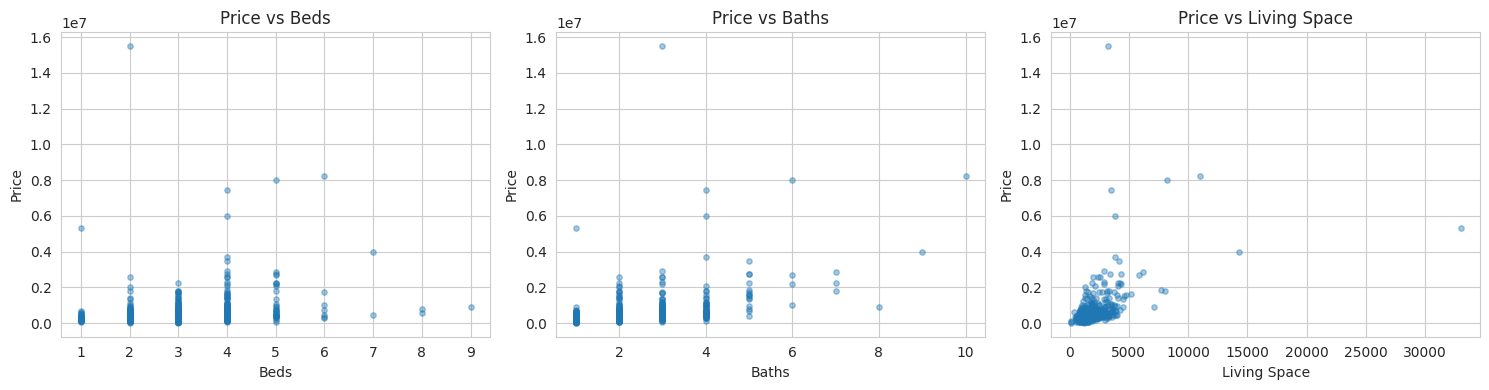

,Beds,Baths,Living Space,Price
Beds,1.000000,0.612960,0.383391,0.190004
Baths,0.612960,1.000000,0.524383,0.424565
Living Space,0.383391,0.524383,1.000000,0.489644
Price,0.190004,0.424565,0.489644,1.000000


In [ ]:
cols = ["Beds", "Baths", "Living Space"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(house[cols[0]], house["Price"], alpha=0.4, s=15)
axes[0].set_xlabel(cols[0])
axes[0].set_ylabel("Price")
axes[0].set_title("Price vs " + cols[0])
axes[1].scatter(house[cols[1]], house["Price"], alpha=0.4, s=15)
axes[1].set_xlabel(cols[1])
axes[1].set_ylabel("Price")
axes[1].set_title("Price vs " + cols[1])
axes[2].scatter(house[cols[2]], house["Price"], alpha=0.4, s=15)
axes[2].set_xlabel(cols[2])
axes[2].set_ylabel("Price")
axes[2].set_title("Price vs " + cols[2])
plt.tight_layout()
plt.show()

house[["Beds", "Baths", "Living Space", "Price"]].corr()

In [ ]:

X = house[["Beds", "Baths", "Living Space"]]
y = house["Price"]
X_const = sm.add_constant(X)

model1 = sm.OLS(y, X_const).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     82.17
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.69e-44
Time:                        00:17:46   Log-Likelihood:                -9035.5
No. Observations:                 600   AIC:                         1.808e+04
Df Residuals:                     596   BIC:                         1.810e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -3.374e+04   1.07e+05     -0.315   

**Interpretation.** The model explains about **29%** of the variance in price (R-squared = 0.293). `Baths` and `Living Space` are positive and highly significant (each additional bathroom is associated with roughly \$275,000 more in price, holding beds and living space fixed; each extra square foot adds about \$219). `Beds` is significant but **negative** (-\$140,700 per bedroom, holding baths and living space fixed) - a classic sign of confounding/multicollinearity: for a fixed living space and bath count, more bedrooms usually means smaller, cheaper rooms (e.g., a studio-converted-to-2-bed vs. a spacious 1-bed), so the coefficient should not be read causally. The intercept is not significantly different from zero.

In [ ]:

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,Beds,8.724504
1,Baths,10.264651
2,Living Space,3.114278


**Multicollinearity.** `Baths` (VIF approx 10.3) and `Beds` (VIF approx 8.7) are both elevated (a common rule of thumb flags VIF > 10 as severe and 5-10 as moderate concern); `Living Space` is fine (VIF approx 3.1). Beds and baths naturally move together in real housing stock, so their individual coefficients should be interpreted cautiously - this is very likely what is producing the counter-intuitive negative sign on `Beds` above.

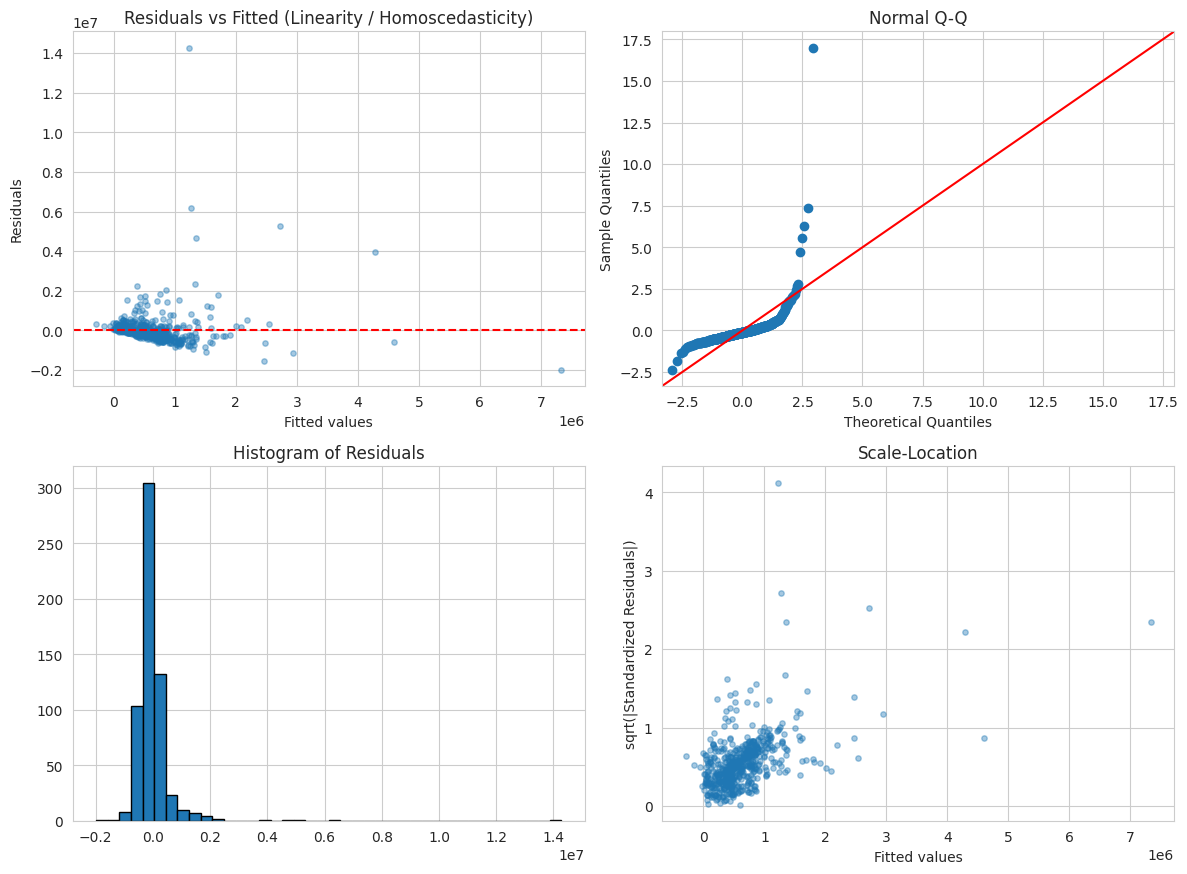

In [ ]:
fitted = model1.fittedvalues
resid = model1.resid
influence = model1.get_influence()
std_resid = influence.resid_studentized_internal

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(fitted, resid, alpha=0.4, s=15)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted (Linearity / Homoscedasticity)")

sm.qqplot(resid, line="45", fit=True, ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q")

axes[1, 0].hist(resid, bins=40, edgecolor="k")
axes[1, 0].set_title("Histogram of Residuals")

axes[1, 1].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, s=15)
axes[1, 1].set_xlabel("Fitted values")
axes[1, 1].set_ylabel("sqrt(|Standardized Residuals|)")
axes[1, 1].set_title("Scale-Location")

plt.tight_layout()
plt.show()

In [ ]:
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(model1.resid, model1.model.exog)
print(f"Breusch-Pagan test  -> LM stat = {bp_stat:.3f}, p-value = {bp_p:.4g}")

shapiro_stat, shapiro_p = stats.shapiro(model1.resid)
print(f"Shapiro-Wilk test   -> W = {shapiro_stat:.3f}, p-value = {shapiro_p:.4g}")

dw = durbin_watson(model1.resid)
print(f"Durbin-Watson stat  -> {dw:.3f}")

Breusch-Pagan test  -> LM stat = 10.110, p-value = 0.01765
Shapiro-Wilk test   -> W = 0.434, p-value = 1.247e-39
Durbin-Watson stat  -> 1.950


### Are the assumptions violated? (raw Price model)

**Linearity.** Violated. The residuals-vs-fitted plot fans out and bends rather than scattering randomly around zero - a handful of very expensive listings dominate the pattern.

**Homoscedasticity.** Violated. The Breusch-Pagan test rejects constant variance (p = 0.018), and the scale-location plot's spread visibly grows with fitted value.

**Normality of residuals.** Violated. Shapiro-Wilk p << 0.001, and the Q-Q plot shows a heavy right tail - a few multi-million-dollar homes create massive positive residuals (skew approx 9.9, kurtosis approx 150).

**Independence of errors.** Not violated. Durbin-Watson approx 1.95, very close to the ideal value of 2, so there is no evidence of autocorrelation (rows are not a genuine time series here anyway).

**Multicollinearity.** Moderate/borderline concern - see VIF discussion above (Beds and Baths approach the common VIF = 10 threshold).

**Bottom line.** This raw-price model violates linearity, homoscedasticity, and normality, all driven by the same cause: a right-skewed price distribution with extreme high-end outliers. The next section tries a log transform of Price to address this.

In [ ]:
y_log = np.log(house["Price"])
model1_log = sm.OLS(y_log, X_const).fit()
print(model1_log.summary())

bp2 = het_breuschpagan(model1_log.resid, model1_log.model.exog)
shapiro2 = stats.shapiro(model1_log.resid)
dw2 = durbin_watson(model1_log.resid)
print(f"\nBreusch-Pagan (log model): p-value = {bp2[1]:.4g}")
print(f"Shapiro-Wilk (log model):  p-value = {shapiro2[1]:.4g}")
print(f"Durbin-Watson (log model): {dw2:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     121.9
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.41e-61
Time:                        00:17:48   Log-Likelihood:                -593.45
No. Observations:                 600   AIC:                             1195.
Df Residuals:                     596   BIC:                             1212.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.0904      0.083    145.657   

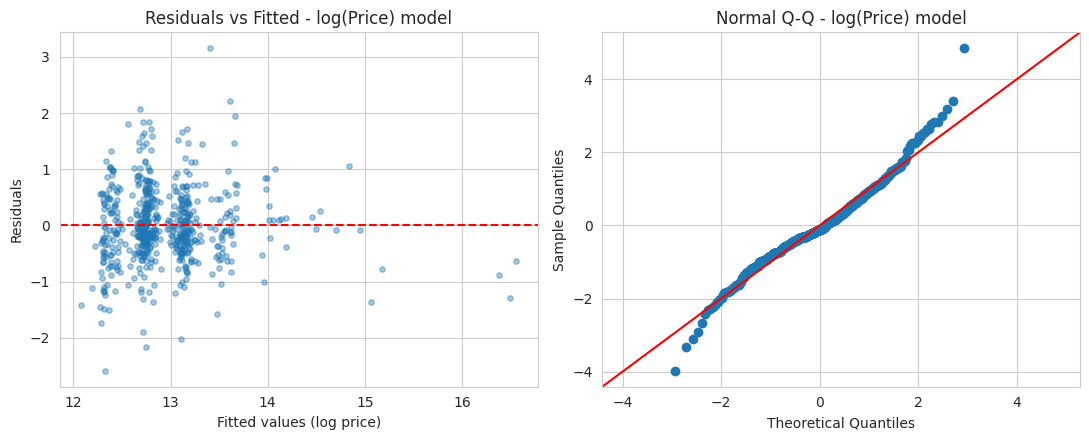

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(model1_log.fittedvalues, model1_log.resid, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values (log price)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted - log(Price) model")

sm.qqplot(model1_log.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q - log(Price) model")
plt.tight_layout()
plt.show()

### Part 1 conclusion

Using Beds, Baths, and Living Space to predict raw Price gives R-squared = 0.293, but the model clearly violates linearity, homoscedasticity, and normality of residuals - all traceable to the extreme right skew of home prices (a small number of multi-million-dollar listings). Independence (Durbin-Watson approx 1.95) is fine, and multicollinearity is only a moderate concern (Beds and Baths VIFs near, but not over, 10).

Log-transforming Price substantially improves things: R-squared rises to about 0.377 (0.364 adjusted), the Breusch-Pagan test no longer rejects constant variance (p = 0.018 to p = 0.549), and residual skew drops from about 9.9 to about 0.34. Shapiro-Wilk is still technically significant (p is very small), so normality is not perfectly satisfied even after the transform, but the Q-Q plot is much closer to the 45-degree line and the residuals-vs-fitted pattern is far more random. In short: the raw-price model is a poor fit for OLS's assumptions, and a log(Price) specification is a meaningfully better - though still imperfect - choice for this dataset.

#PART 2

We're using this data from Kaggle for MULTIPLE LINEAR REGRESSION:

[Advertising data](https://www.kaggle.com/code/shrutimechlearn/step-by-step-assumptions-linear-regression/input)

Investigate sales as the dependent variable, the rest of the columns are the predictors.

Note: Make sure to check assumptions. Are there assumptions that are violated?

In [ ]:
# Advertising dataset (200 rows) embedded inline.
advertising_csv = """TV,Radio,Newspaper,Sales
230.1,37.8,69.2,22.1
44.5,39.3,45.1,10.4
17.2,45.9,69.3,9.3
151.5,41.3,58.5,18.5
180.8,10.8,58.4,12.9
8.7,48.9,75.0,7.2
57.5,32.8,23.5,11.8
120.2,19.6,11.6,13.2
8.6,2.1,1.0,4.8
199.8,2.6,21.2,10.6
66.1,5.8,24.2,8.6
214.7,24.0,4.0,17.4
23.8,35.1,65.9,9.2
97.5,7.6,7.2,9.7
204.1,32.9,46.0,19.0
195.4,47.7,52.9,22.4
67.8,36.6,114.0,12.5
281.4,39.6,55.8,24.4
69.2,20.5,18.3,11.3
147.3,23.9,19.1,14.6
218.4,27.7,53.4,18.0
237.4,5.1,23.5,12.5
13.2,15.9,49.6,5.6
228.3,16.9,26.2,15.5
62.3,12.6,18.3,9.7
262.9,3.5,19.5,12.0
142.9,29.3,12.6,15.0
240.1,16.7,22.9,15.9
248.8,27.1,22.9,18.9
70.6,16.0,40.8,10.5
292.9,28.3,43.2,21.4
112.9,17.4,38.6,11.9
97.2,1.5,30.0,9.6
265.6,20.0,0.3,17.4
95.7,1.4,7.4,9.5
290.7,4.1,8.5,12.8
266.9,43.8,5.0,25.4
74.7,49.4,45.7,14.7
43.1,26.7,35.1,10.1
228.0,37.7,32.0,21.5
202.5,22.3,31.6,16.6
177.0,33.4,38.7,17.1
293.6,27.7,1.8,20.7
206.9,8.4,26.4,12.9
25.1,25.7,43.3,8.5
175.1,22.5,31.5,14.9
89.7,9.9,35.7,10.6
239.9,41.5,18.5,23.2
227.2,15.8,49.9,14.8
66.9,11.7,36.8,9.7
199.8,3.1,34.6,11.4
100.4,9.6,3.6,10.7
216.4,41.7,39.6,22.6
182.6,46.2,58.7,21.2
262.7,28.8,15.9,20.2
198.9,49.4,60.0,23.7
7.3,28.1,41.4,5.5
136.2,19.2,16.6,13.2
210.8,49.6,37.7,23.8
210.7,29.5,9.3,18.4
53.5,2.0,21.4,8.1
261.3,42.7,54.7,24.2
239.3,15.5,27.3,15.7
102.7,29.6,8.4,14.0
131.1,42.8,28.9,18.0
69.0,9.3,0.9,9.3
31.5,24.6,2.2,9.5
139.3,14.5,10.2,13.4
237.4,27.5,11.0,18.9
216.8,43.9,27.2,22.3
199.1,30.6,38.7,18.3
109.8,14.3,31.7,12.4
26.8,33.0,19.3,8.8
129.4,5.7,31.3,11.0
213.4,24.6,13.1,17.0
16.9,43.7,89.4,8.7
27.5,1.6,20.7,6.9
120.5,28.5,14.2,14.2
5.4,29.9,9.4,5.3
116.0,7.7,23.1,11.0
76.4,26.7,22.3,11.8
239.8,4.1,36.9,12.3
75.3,20.3,32.5,11.3
68.4,44.5,35.6,13.6
213.5,43.0,33.8,21.7
193.2,18.4,65.7,15.2
76.3,27.5,16.0,12.0
110.7,40.6,63.2,16.0
88.3,25.5,73.4,12.9
109.8,47.8,51.4,16.7
134.3,4.9,9.3,11.2
28.6,1.5,33.0,7.3
217.7,33.5,59.0,19.4
250.9,36.5,72.3,22.2
107.4,14.0,10.9,11.5
163.3,31.6,52.9,16.9
197.6,3.5,5.9,11.7
184.9,21.0,22.0,15.5
289.7,42.3,51.2,25.4
135.2,41.7,45.9,17.2
222.4,4.3,49.8,11.7
296.4,36.3,100.9,23.8
280.2,10.1,21.4,14.8
187.9,17.2,17.9,14.7
238.2,34.3,5.3,20.7
137.9,46.4,59.0,19.2
25.0,11.0,29.7,7.2
90.4,0.3,23.2,8.7
13.1,0.4,25.6,5.3
255.4,26.9,5.5,19.8
225.8,8.2,56.5,13.4
241.7,38.0,23.2,21.8
175.7,15.4,2.4,14.1
209.6,20.6,10.7,15.9
78.2,46.8,34.5,14.6
75.1,35.0,52.7,12.6
139.2,14.3,25.6,12.2
76.4,0.8,14.8,9.4
125.7,36.9,79.2,15.9
19.4,16.0,22.3,6.6
141.3,26.8,46.2,15.5
18.8,21.7,50.4,7.0
224.0,2.4,15.6,11.6
123.1,34.6,12.4,15.2
229.5,32.3,74.2,19.7
87.2,11.8,25.9,10.6
7.8,38.9,50.6,6.6
80.2,0.0,9.2,8.8
220.3,49.0,3.2,24.7
59.6,12.0,43.1,9.7
0.7,39.6,8.7,1.6
265.2,2.9,43.0,12.7
8.4,27.2,2.1,5.7
219.8,33.5,45.1,19.6
36.9,38.6,65.6,10.8
48.3,47.0,8.5,11.6
25.6,39.0,9.3,9.5
273.7,28.9,59.7,20.8
43.0,25.9,20.5,9.6
184.9,43.9,1.7,20.7
73.4,17.0,12.9,10.9
193.7,35.4,75.6,19.2
220.5,33.2,37.9,20.1
104.6,5.7,34.4,10.4
96.2,14.8,38.9,11.4
140.3,1.9,9.0,10.3
240.1,7.3,8.7,13.2
243.2,49.0,44.3,25.4
38.0,40.3,11.9,10.9
44.7,25.8,20.6,10.1
280.7,13.9,37.0,16.1
121.0,8.4,48.7,11.6
197.6,23.3,14.2,16.6
171.3,39.7,37.7,19.0
187.8,21.1,9.5,15.6
4.1,11.6,5.7,3.2
93.9,43.5,50.5,15.3
149.8,1.3,24.3,10.1
11.7,36.9,45.2,7.3
131.7,18.4,34.6,12.9
172.5,18.1,30.7,14.4
85.7,35.8,49.3,13.3
188.4,18.1,25.6,14.9
163.5,36.8,7.4,18.0
117.2,14.7,5.4,11.9
234.5,3.4,84.8,11.9
17.9,37.6,21.6,8.0
206.8,5.2,19.4,12.2
215.4,23.6,57.6,17.1
284.3,10.6,6.4,15.0
50.0,11.6,18.4,8.4
164.5,20.9,47.4,14.5
19.6,20.1,17.0,7.6
168.4,7.1,12.8,11.7
222.4,3.4,13.1,11.5
276.9,48.9,41.8,27.0
248.4,30.2,20.3,20.2
170.2,7.8,35.2,11.7
276.7,2.3,23.7,11.8
165.6,10.0,17.6,12.6
156.6,2.6,8.3,10.5
218.5,5.4,27.4,12.2
56.2,5.7,29.7,8.7
287.6,43.0,71.8,26.2
253.8,21.3,30.0,17.6
205.0,45.1,19.6,22.6
139.5,2.1,26.6,10.3
191.1,28.7,18.2,17.3
286.0,13.9,3.7,15.9
18.7,12.1,23.4,6.7
39.5,41.1,5.8,10.8
75.5,10.8,6.0,9.9
17.2,4.1,31.6,5.9
166.8,42.0,3.6,19.6
149.7,35.6,6.0,17.3
38.2,3.7,13.8,7.6
94.2,4.9,8.1,9.7
177.0,9.3,6.4,12.8
283.6,42.0,66.2,25.5
232.1,8.6,8.7,13.4
"""
adv = pd.read_csv(StringIO(advertising_csv))
print(adv.shape)
adv.head()

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
adv.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


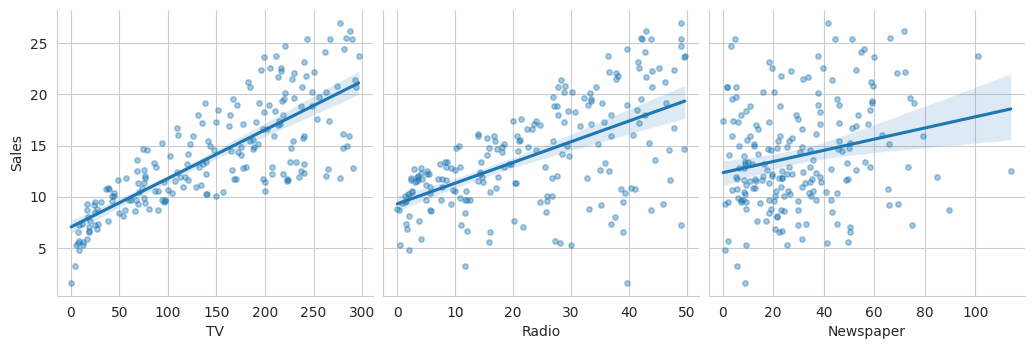

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [ ]:
sns.pairplot(adv, x_vars=["TV", "Radio", "Newspaper"], y_vars="Sales", kind="reg", height=3.5, plot_kws={"scatter_kws": {"alpha": 0.4, "s": 15}})
plt.show()

adv.corr()

In [ ]:
X2 = adv[["TV", "Radio", "Newspaper"]]
y2 = adv["Sales"]
X2_const = sm.add_constant(X2)

model2 = sm.OLS(y2, X2_const).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        00:17:51   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

**Interpretation.** This model explains about **90%** of the variance in Sales (R-squared = 0.897). `TV` and `Radio` are both highly significant with positive coefficients: an extra \$1,000 in TV spend is associated with about 45.8 more units sold, and an extra \$1,000 in Radio spend with about 188.5 more units sold (holding the other predictors fixed) - Radio appears far more efficient per dollar than TV. `Newspaper` is **not significant** (p = 0.860); its tiny negative coefficient is indistinguishable from zero, suggesting newspaper spend has little to no independent effect on sales once TV and Radio are accounted for.

In [ ]:
vif2 = pd.DataFrame()
vif2["Variable"] = X2.columns
vif2["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
vif2

,Variable,VIF
0,TV,2.486772
1,Radio,3.285462
2,Newspaper,3.055245


**Multicollinearity.** All VIF values are low (TV approx 2.5, Radio approx 3.3, Newspaper approx 3.1 - all well under the common threshold of 5), so multicollinearity is not a concern for this model.

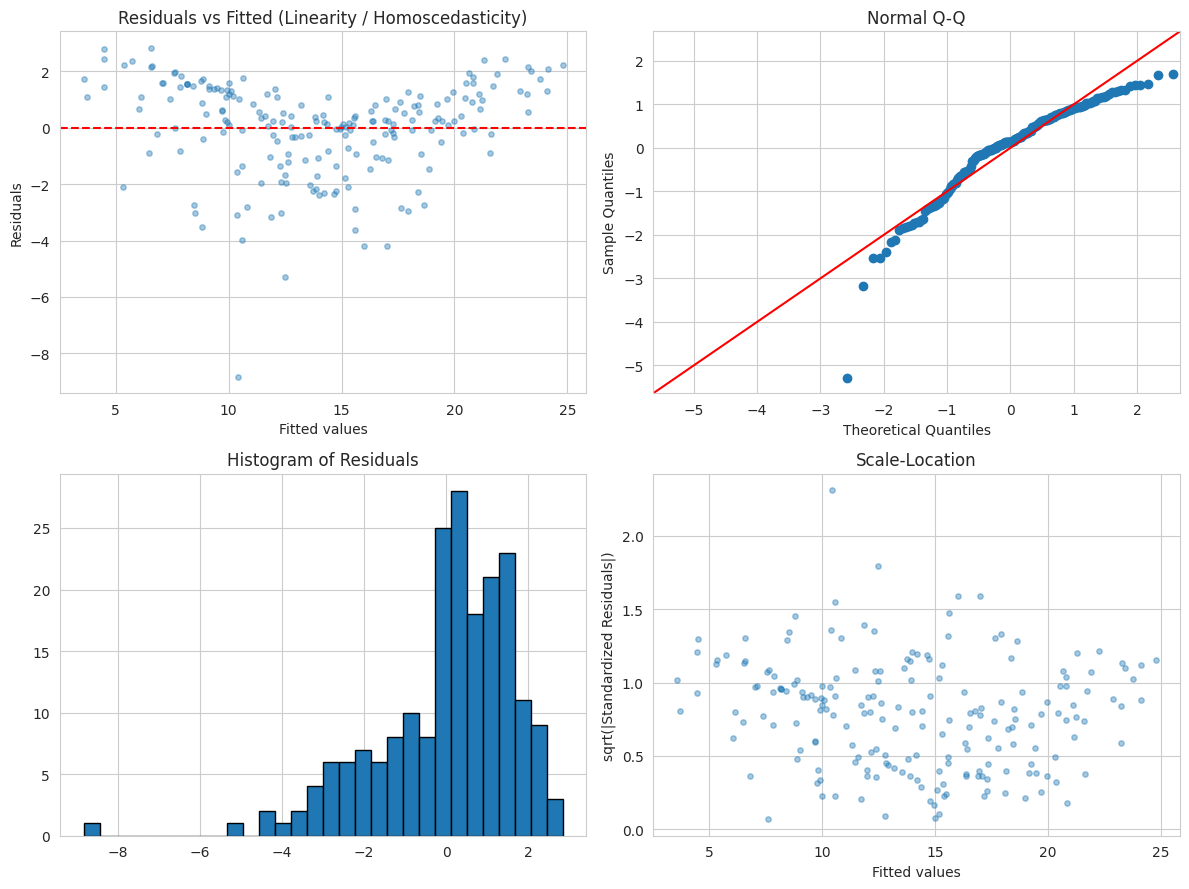

In [ ]:
fitted2 = model2.fittedvalues
resid2 = model2.resid
influence2 = model2.get_influence()
std_resid2 = influence2.resid_studentized_internal

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(fitted2, resid2, alpha=0.4, s=15)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted (Linearity / Homoscedasticity)")

sm.qqplot(resid2, line="45", fit=True, ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q")

axes[1, 0].hist(resid2, bins=30, edgecolor="k")
axes[1, 0].set_title("Histogram of Residuals")

axes[1, 1].scatter(fitted2, np.sqrt(np.abs(std_resid2)), alpha=0.4, s=15)
axes[1, 1].set_xlabel("Fitted values")
axes[1, 1].set_ylabel("sqrt(|Standardized Residuals|)")
axes[1, 1].set_title("Scale-Location")

plt.tight_layout()
plt.show()

In [ ]:
bp_stat2, bp_p2, bp_f2, bp_fp2 = het_breuschpagan(model2.resid, model2.model.exog)
print(f"Breusch-Pagan test  -> LM stat = {bp_stat2:.3f}, p-value = {bp_p2:.4g}")

shapiro_stat2, shapiro_p2 = stats.shapiro(model2.resid)
print(f"Shapiro-Wilk test   -> W = {shapiro_stat2:.3f}, p-value = {shapiro_p2:.4g}")

dw2b = durbin_watson(model2.resid)
print(f"Durbin-Watson stat  -> {dw2b:.3f}")

Breusch-Pagan test  -> LM stat = 5.133, p-value = 0.1623
Shapiro-Wilk test   -> W = 0.918, p-value = 3.939e-09
Durbin-Watson stat  -> 2.084


### Are the assumptions violated?

**Linearity.** Mildly violated. The residuals-vs-fitted plot is mostly random scatter, but there is a slight curved/fanning pattern at low fitted values (a handful of very-low-Sales points with large negative residuals), suggesting the true TV-Sales and Radio-Sales relationships may be slightly nonlinear (a synergy/interaction effect, explored below).

**Homoscedasticity.** Not violated. Breusch-Pagan p = 0.162, so we fail to reject constant variance.

**Normality of residuals.** Violated. Shapiro-Wilk p << 0.001, and the residuals are left-skewed (skew approx -1.33) - a cluster of low-Sales campaigns produces unusually large negative residuals.

**Independence of errors.** Not violated. Durbin-Watson approx 2.08, close to the ideal value of 2.

**Multicollinearity.** Not violated. All VIFs are low (approx 2.5-3.3), well under common thresholds.

**Bottom line.** This model is in much better shape than the housing model: R-squared is high (0.897), variance is constant, errors are independent, and there's no multicollinearity. The main issue is non-normal (left-skewed) residuals and a hint of nonlinearity, both likely driven by the TV*Radio synergy effect explored in the bonus model below.

In [ ]:
adv["TV_Radio"] = adv["TV"] * adv["Radio"]

X3 = adv[["TV", "Radio", "TV_Radio"]]
X3_const = sm.add_constant(X3)
model3 = sm.OLS(y2, X3_const).fit()
print(model3.summary())

bp3 = het_breuschpagan(model3.resid, model3.model.exog)
shapiro3 = stats.shapiro(model3.resid)
dw3 = durbin_watson(model3.resid)
print(f"\nBreusch-Pagan (interaction model): p-value = {bp3[1]:.4g}")
print(f"Shapiro-Wilk (interaction model):  p-value = {shapiro3[1]:.4g}")
print(f"Durbin-Watson (interaction model): {dw3:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1963.
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          6.68e-146
Time:                        00:17:54   Log-Likelihood:                -270.14
No. Observations:                 200   AIC:                             548.3
Df Residuals:                     196   BIC:                             561.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7502      0.248     27.233      0.0

**Part 2 conclusion**

For the Advertising dataset, the base model (Sales ~ TV + Radio + Newspaper) fits the data well, with R-squared = 0.897. TV and Radio are both strong, statistically significant predictors, while Newspaper is not significant once TV and Radio are accounted for. VIF values are all low (TV approx 2.5, Radio approx 3.3, Newspaper approx 3.1), so multicollinearity is not a concern. However, the Breusch-Pagan test (p = 0.1623) is only borderline for homoscedasticity, and the Shapiro-Wilk test (p = 3.939e-09) shows the residuals are not normally distributed - both issues driven in part by a TV*Radio synergy effect explored in the bonus model below.

The bonus interaction model (adding a TV*Radio term) raises R-squared to 0.968, and the interaction term itself is highly significant (p < 0.001), confirming that the effect of TV spend on Sales depends on the level of Radio spend, and vice versa. This improvement in fit comes at a cost, though: the Breusch-Pagan p-value drops to 0.002495 (heteroscedasticity is now a real concern) and the Shapiro-Wilk p-value drops further to 3.047e-13 (even worse non-normality of the residuals). The Durbin-Watson statistic (2.224) still indicates no strong autocorrelation.

Overall, the interaction model is the better predictive fit, but a practitioner should be cautious about trusting its raw p-values and confidence intervals at face value, since two of the four classical OLS assumptions (homoscedasticity and normality) are violated more severely than in the base model. Robust (heteroscedasticity-consistent) standard errors, or a transformation of the response variable, would be reasonable next steps before relying on inferential statistics from this model.